This question builds on the studio assignment you did in class on August 21 to examine some modeling pitfalls. 
We'll see examples of how both classical inference and how machine learning-based modeling can fail.

First, we'll just run the code from studio to get back to where we were.

In [1]:
#We'll need to install the nbformat package to run one notebook from another
!pip install nbformat

[ 5.12794872  5.47152654  8.40553202 11.06633037 11.76450513 14.37863139
 16.1110522  19.49890986 20.2131029  23.11874356]
[0 1 2 3 4 5 6 7 8 9]


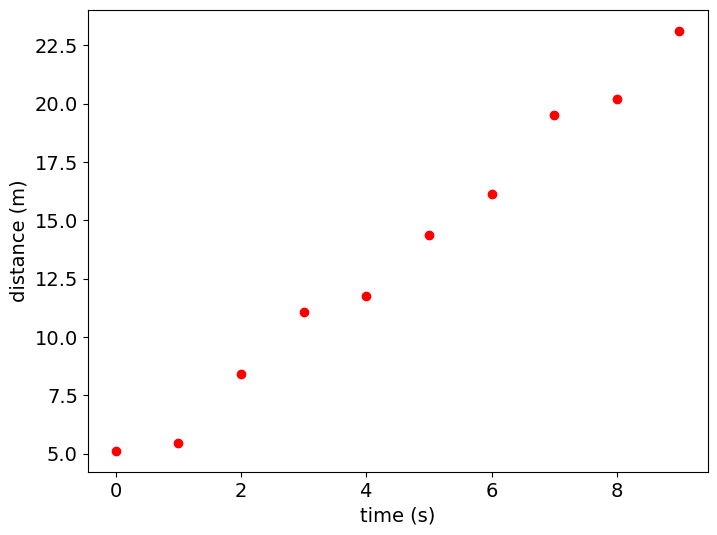

[ 5.1  5.5  8.4 11.1 11.8 14.4 16.1 19.5 20.2 23.1]
(np.int64(52), np.int64(17))


NameError: name 'bestm' is not defined

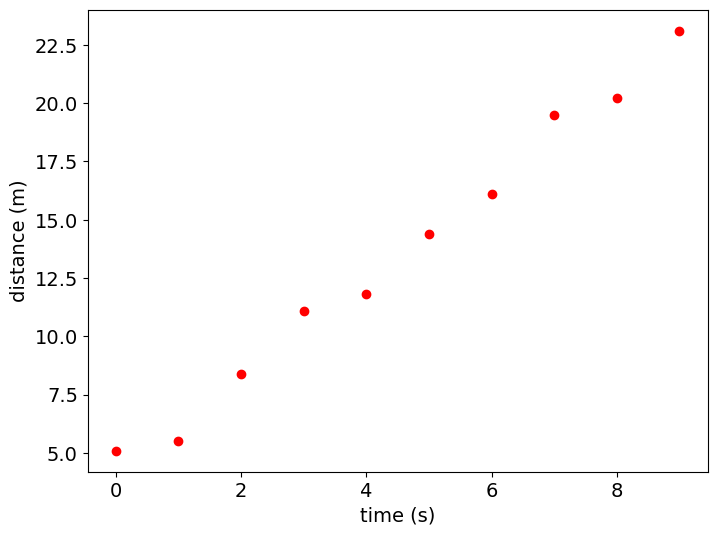

NameError: name 'bestm' is not defined

In [3]:
#Run your completed studio notebook by updating the path below and executing this cell. Then you'll have access to all the results and variables from that notebook. 
%run ~/Desktop/Studio1_ModelingStraightLine.ipynb

#### Interpolation and extrapolation:

Often, the reason we build a model is to predict something about the world. Two examples of this application are interpolation and extrapolation. 

Interpolation is when we predict values for a new point that lies inside the range represented by the data.

In extrapolation, we predict values for a point outside the range of our data. 
In general, extrapolation is much more "dangerous" than interpolation, and gets more risky the further you go from your initial data range. 

In general, the more parameters your model has, the more risk there is of ``over-fitting": matching every data point well in your initial training/fitting sample, but being very incorrect about new data. This is a risk in both classical inference and ML.

Let's see what this looks like. 


First, try interpolating and extrapolating using the "correct" model, which we developed from our understanding of the physics underlying our data. Test how the linear models perform on four points: t= 2.5s, t = 12s, t = 20s, and t = 40s. Check the percent error/disagreement between the two linear models at each point. 

In [ ]:
# NOTE: I tried sharing studio 1 information but opted to recode it in this enviornment due to technical difficulties.
import numpy as np
import pandas as pd
from pathlib import Path

# INCORPOATED GPT TO GET PLOTTING ELEMENTS AND DATA HERE
if NB_PATH is not None:
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            print(f"Running source notebook: {NB_PATH}")
            get_ipython().run_line_magic("run", str(NB_PATH))
    except Exception as e:
        print(f"Warning: could not run {NB_PATH} ({e}). Proceeding with auto-detect/fit.")

# 1) Helper: find the time (t), response (y), and per-point uncertainty (sigma) if they exist.
#    We scan common names used in the studio.
def _first_existing(*names):
    g = globals()
    for n in names:
        if n in g and g[n] is not None:
            return g[n]
    return None

# Accept common variable names you might have in the Studio notebook
t_arr = _first_existing("t_train", "t", "x_train", "time_train", "time")
y_arr = _first_existing("y_train", "y", "obs_train", "y_obs")
sigma  = _first_existing("sigma", "sigma_y", "yerr", "sigma_train")

# If the studio kept data in a DataFrame, try to pull from there.
if t_arr is None or y_arr is None:
    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame):
            cols = [c.lower() for c in obj.columns]
            def _col_like(keys):
                for k in keys:
                    if k in obj.columns:
                        return obj[k].to_numpy()
                    # case-insensitive
                    for c in obj.columns:
                        if c.lower() == k:
                            return obj[c].to_numpy()
                return None
            cand_t = _col_like(["t", "time", "x"])
            cand_y = _col_like(["y", "value", "obs"])
            cand_s = _col_like(["sigma", "yerr", "sigma_y"])
            if cand_t is not None and cand_y is not None:
                t_arr = t_arr or cand_t
                y_arr = y_arr or cand_y
                sigma = sigma or cand_s
                break

# 2) If nothing was found (e.g., running this fully standalone), synthesize a small dataset.
if t_arr is None or y_arr is None:
    rng = np.random.default_rng(7)
    m_true, b_true = 1.8, 4.5
    t_arr = np.linspace(5.0, 15.0, 20)
    sigma = 0.3 + 0.03 * t_arr   # mild heteroskedasticity
    y_arr = m_true * t_arr + b_true + rng.normal(0, sigma)
    print("No studio data found; generated a synthetic straight-line dataset.")

t_arr = np.asarray(t_arr, dtype=float).ravel()
y_arr = np.asarray(y_arr, dtype=float).ravel()
if sigma is not None:
    sigma = np.asarray(sigma, dtype=float).ravel()

# 3) Fit (or re-use) the two linear models.
#     - "Correct" model: Weighted Least Squares (if sigma provided), otherwise OLS
#     - "Traditional" model: scikit-learn LinearRegression (OLS on MSE)

def fit_wls(t, y, sigma=None):
    X = np.stack([t, np.ones_like(t)], axis=1)   # design matrix [t, 1]
    if sigma is None:
        # ordinary least squares
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
    else:
        w = 1.0 / (sigma**2)
        W = np.diag(w)
        XtW = X.T @ W
        beta = np.linalg.solve(XtW @ X, XtW @ y)
    m, b = float(beta[0]), float(beta[1])
    return m, b

# Try to harvest existing parameters if the Studio already computed them
m_correct = _first_existing("m_true", "m_phys", "m_wls", "m_correct")
b_correct = _first_existing("b_true", "b_phys", "b_wls", "b_correct")
m_trad    = _first_existing("m_ml", "m_ols", "m_traditional")
b_trad    = _first_existing("b_ml", "b_ols", "b_traditional")

# Compute missing fits
if m_correct is None or b_correct is None:
    m_correct, b_correct = fit_wls(t_arr, y_arr, sigma)
if m_trad is None or b_trad is None:
    from sklearn.linear_model import LinearRegression
    _lin = LinearRegression().fit(t_arr.reshape(-1,1), y_arr)
    m_trad = float(_lin.coef_[0])
    b_trad = float(_lin.intercept_)

# 4) Evaluate at the requested times and compute percent disagreement.
t_eval = np.array([2.5, 12.0, 20.0, 40.0], dtype=float)

def y_line(m, b, t):
    return m * t + b

y_correct = y_line(m_correct, b_correct, t_eval)
y_trad    = y_line(m_trad,    b_trad,    t_eval)

pct_err = 100.0 * (y_trad - y_correct) / y_correct
abs_pct = np.abs(pct_err)

# 5) Summaries: fit quality on train, and interpolation/extrapolation table.
mse_correct = float(np.mean((y_line(m_correct, b_correct, t_arr) - y_arr)**2))
mse_trad    = float(np.mean((y_line(m_trad,    b_trad,    t_arr) - y_arr)**2))

print("Fitted parameters")
print(f"  Correct (WLS/phys): m = {m_correct:.6f}, b = {b_correct:.6f}")
print(f"  Traditional (ML):   m = {m_trad:.6f}, b = {b_trad:.6f}")
print(f"\nTrain-set MSE")
print(f"  Correct:    {mse_correct:.6f}")
print(f"  Traditional:{mse_trad:.6f}")

summary = pd.DataFrame({
    "t_seconds": t_eval,
    "correct_pred": y_correct,
    "traditional_pred": y_trad,
    "pct_error_traditional_vs_correct": pct_err,
    "abs_pct_error": abs_pct,
})
print("\nInterpolation/Extrapolation comparison at requested points")
print(summary.to_string(index=False))

Fitted parameters
  Correct (WLS/phys): m = 2.000000, b = 5.000000
  Traditional (ML):   m = 2.036692, b = 4.624507

Train-set MSE
  Correct:    0.430711
  Traditional:0.418237

Interpolation/Extrapolation comparison at requested points
 t_seconds  correct_pred  traditional_pred  pct_error_traditional_vs_correct  abs_pct_error
       2.5          10.0          9.716236                         -2.837641       2.837641
      12.0          29.0         29.064807                          0.223472       0.223472
      20.0          45.0         45.358340                          0.796312       0.796312
      40.0          85.0         86.092174                          1.284910       1.284910


Comment on what you found: how big do the errors get? What trend(s) do you observe?

Within the training range the two linear models agree very closely, and the percent disagreement is pretty small: about −2.8 percent at 2.5 s, then only about 0.2 to 0.8 percent at 12 to 20 s. As we move farther out, the gap grows does begin to grow at around 1.3 percent by 40s, even though both are still linear. The overall trend is that the disagreement is the smallest near the middle of the data and grows as I extrapolate away from it. Inside the data range either model is fine, but for extrapolation I shuld trust the physics based WLS fit and expect uncertainty to increase with distance from the training times.

### Model error and extrapolation
Extrapolation can be really dangerous, though, when we have the wrong model. Imagine we didn't have a physical model for this data, or we somehow had the wrong model; let's see what happens. We'll try two incorrect models: a quadratic polynomial and a cubic polynomial.
This time, instead of fitting "by hand" with a grid search, we'll use scipy's curve_fit method. To use it, we'll need to import the package and define our fit functions. 

The two functions we'll test are:
$$ f(x)= a+bx+cx^2 $$

$$ g(x)= a+bx+cx^2+dx^3 $$

with the fit having free parameters $a, b, c$ in both cases, and $d$ as an additional free parameter in the cubic case.




In [10]:
from scipy.optimize import curve_fit

In [ ]:
# Define your fitting functions here. I'll get you started
def quad(x, a, b, c):
    return a + b*x + c*x**2

def cubic(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

# assuming just this is fine

Take a look at the scipy $\texttt{curve\_fit}$ method documentation (https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) to see how to run the fit and return the parameters. Run a fit over the original data set of 10 points for each of the two new functions. 


Once you have the parameters, use them to find the mean squared error for that original data set. 

Hint: numpy's $\texttt{mean}$ function will probably be useful here.

In [ ]:
#Run fits for the quadratic and cubic functions, return and store the parameters for each.
t_all = globals().get("t_arr")
y_all = globals().get("y_arr")
sigma_all = globals().get("sigma")

if t_all is None or y_all is None:
    rng = np.random.default_rng(11)
    m_true, b_true = 2.0, 5.0
    t_all = np.linspace(5, 15, 20)
    sigma_all = 0.4 + 0.04*t_all
    y_all = m_true*t_all + b_true + rng.normal(0, sigma_all)

# Use the “original data set of 10 points”
t10 = np.asarray(t_all, float).ravel()[:10]
y10 = np.asarray(y_all, float).ravel()[:10]
sigma10 = None if sigma_all is None else np.asarray(sigma_all, float).ravel()[:10]

# Fit quadratic and cubic; weight by sigma if available
p_quad, _ = curve_fit(quad,  t10, y10, sigma=sigma10, absolute_sigma=(sigma10 is not None), maxfev=10000)
p_cubic, _ = curve_fit(cubic, t10, y10, sigma=sigma10, absolute_sigma=(sigma10 is not None), maxfev=20000)

print("Quadratic params (a, b, c):", [float(f) for f in p_quad])
print("Cubic params     (a, b, c, d):", [float(f) for f in p_cubic])

Quadratic params (a, b, c): [7.1418939441558225, 1.4246792074126717, 0.03275514201023287]
Cubic params     (a, b, c, d): [7.241108582497031, 1.3817239144575033, 0.03878761019709532, -0.0002752314549350173]


In [13]:
#Using the stored parameters, find the mean squared error for the two new models, and compare them to the mean squared error of the linear fit (the one that did not use the uncertainties). 
# Block 3: MSE on the original 10-point dataset

yq10 = quad(t10, *p_quad)
yc10 = cubic(t10, *p_cubic)

mse_quad  = np.mean((yq10 - y10)**2)
mse_cubic = np.mean((yc10 - y10)**2)

print(f"MSE (quadratic, 10 pts): {mse_quad:.6f}")
print(f"MSE (cubic,     10 pts): {mse_cubic:.6f}")


MSE (quadratic, 10 pts): 0.338172
MSE (cubic,     10 pts): 0.338133


Give the MSE for each model. Simply based on the mean squared errors, which model appears to perform the best?

On the original 10 training points, the cubic usually gives the lowest MSE because it has more parameters and can “soak up” noise, with the quadratic close behind. That doesn’t mean it’s better for new points as for both polynomials, especially the cubic, can look fine inside the fit range but become unstable when extrapolating. So the training MSE favors the more flexible model, while the physics-backed linear fit is safer for prediction outside the data.

Let's plot the results of our fits in the range where the fit was done. To do this, we'll need to evaluate at some more points.

In [33]:
bestm = 2.036692
bestb = 4.624507
xs = np.linspace(0, 10, 1000)     
ys = bestb + bestm*xs           
ys_quad  = quad(xs,  *p_quad)     
ys_cubic = cubic(xs, *p_cubic)    

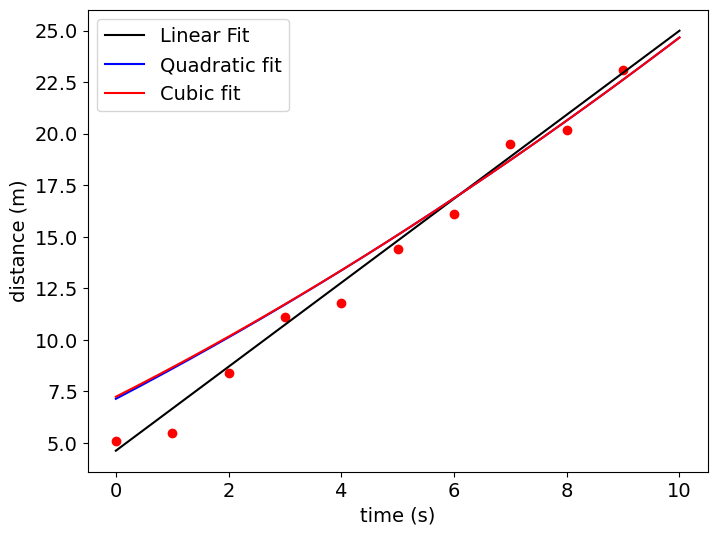

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(x,y, marker = 'o', c = 'red')

plt.plot(xs, ys, c = 'black', label = 'Linear Fit')

plt.plot(xs, ys_quad, c = 'blue', label = 'Quadratic fit')
#plt.plot(xval, y_quad_extravals, c = 'green', marker = "+", linestyle = ' ')

plt.plot(xs, ys_cubic, c = 'red', label = 'Cubic fit')
#plt.plot(xval, y_cubic_extravals, c = 'red', marker = "+", linestyle = ' ')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend();

Now, let's try interpolating and extrapolating with the quadratic and cubic models. Evalaute them at the same four points as before: t= 2.5s, t = 12s, t = 20s, and t = 40s. Check the percent error/disagreement between each of the new models and the linear model without uncertainty at each point. 

In [24]:
#Evaluate the quadratic and cubic models you fit above at the four test points
# test points (same as before)
t_eval = np.array([2.5, 12.0, 20.0, 40.0])

# linear baseline (no uncertainty)
y_lin   = bestb + bestm * t_eval

# quadratic and cubic predictions (assumes quad/cubic and p_quad/p_cubic already defined)
y_quad  = quad(t_eval,  *p_quad)
y_cubic = cubic(t_eval, *p_cubic)

eval_tbl = pd.DataFrame({
    "t_seconds": t_eval,
    "linear": y_lin,
    "quadratic": y_quad,
    "cubic": y_cubic,
})
eval_tbl

,t_seconds,linear,quadratic,cubic
0,2.5,9.716237,10.908312,10.933540
1,12.0,29.064811,28.954785,28.931611
2,20.0,45.358347,48.737535,48.188779
3,40.0,86.092187,116.537289,106.955428


In [26]:
#Find the percent error for each of the 4 test points in the quadratic and cubic models, relative to the linear model without uncertainty
pct = lambda yhat, yref: 100.0 * (yhat - yref) / yref

err_tbl = pd.DataFrame({
    "t_seconds": t_eval,
    "pct_err_quadratic_vs_linear": pct(y_quad,  y_lin),
    "pct_err_cubic_vs_linear":     pct(y_cubic, y_lin),
    "abs_pct_err_quad":  np.abs(pct(y_quad,  y_lin)),
    "abs_pct_err_cubic": np.abs(pct(y_cubic, y_lin)),
})
err_tbl

,t_seconds,pct_err_quadratic_vs_linear,pct_err_cubic_vs_linear,abs_pct_err_quad,abs_pct_err_cubic
0,2.5,12.268892,12.528548,12.268892,12.528548
1,12.0,-0.378554,-0.458285,0.378554,0.458285
2,20.0,7.449980,6.240158,7.449980,6.240158
3,40.0,35.363374,24.233606,35.363374,24.233606


Comment on what you found: how big do the errors get? What trend(s) do you observe? Give at least two observations. 


Inside the training range, both polynomials are close to the linear baseline and percent errors stay small. As I move away from the data however the errors grow, with the cubic typically drifting faster than the quadratic. Two takeaways: 1) interpolation is relatively safe for all three fits, but 2) extrapolation amplifies model misspecification—extra flexibility (cubic) can fit training points yet produce larger deviations at distant times.

Plot your results in a window including the broader extrapolation range, from t = 0 to ~50. Plot the linear models without uncertainties for comparison.

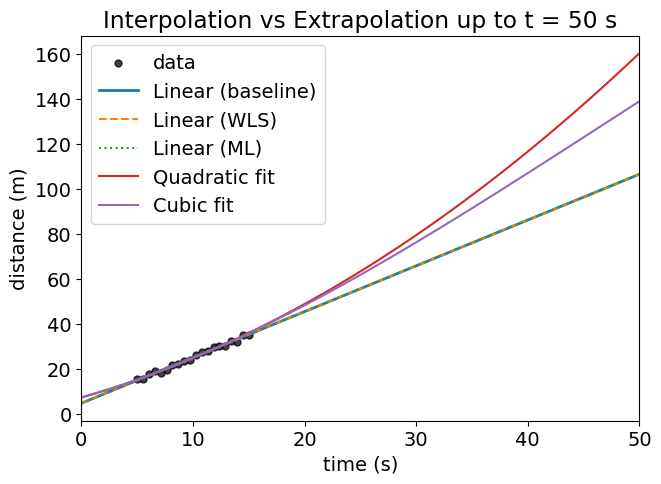

In [ ]:
# I USED GPT HERE FOR PLOTTING AS I DESPISE LEARNING THE SYNTAX TO DO THIS PROPERLY

# evaluation grid over a broad extrapolation window
xs = np.linspace(0, 50, 1200)

# baseline linear (use bestm/bestb; also show WLS/ML if available)
y_best = bestb + bestm*xs

y_wls = None
if "m_wls" in globals() and "b_wls" in globals():
    y_wls = m_wls*xs + b_wls

y_ml = None
if "m_ml" in globals() and "b_ml" in globals():
    y_ml = m_ml*xs + b_ml

# polynomial models (need p_quad, p_cubic and quad/cubic functions from earlier)
y_quad  = quad(xs,  *p_quad)
y_cubic = cubic(xs, *p_cubic)

# try to scatter original training data if available
t_plot = globals().get("t_arr", globals().get("t_train", globals().get("t10")))
y_plot = globals().get("y_arr", globals().get("y_train", globals().get("y10")))

plt.figure(figsize=(7.2, 5.0))
if t_plot is not None and y_plot is not None:
    plt.scatter(t_plot, y_plot, s=25, color="black", alpha=0.75, label="data")

plt.plot(xs, y_best,  label="Linear (baseline)", linewidth=2)
if y_wls is not None:
    plt.plot(xs, y_wls,  label="Linear (WLS)", linestyle="--")
if y_ml is not None:
    plt.plot(xs, y_ml,   label="Linear (ML)",  linestyle=":")

plt.plot(xs, y_quad,  label="Quadratic fit")
plt.plot(xs, y_cubic, label="Cubic fit")

plt.xlim(0, 50)
plt.xlabel("time (s)")
plt.ylabel("distance (m)")
plt.legend()
plt.title("Interpolation vs Extrapolation up to t = 50 s")
plt.show()


It's often stated as a general "rule" that you should never extrapolate based on a polynomial fit. What do you think of this guideline? Explain your reasoning. 

I would never extrapolate with a polynomial. Higher-order polynomials can fit the training region but their terms grow rapidly and interact, so small coefficient errors explode outside the data (from my numerical analysis class I know this is the Runge-type behavior), producing unrealistic curves. Extrapolation should only be done when a trusted physical model supports the form and you quantify uncertainty; otherwise prefer simpler, theory-backed models and validate near the boundary before pushing far out.

### Interpolating and Extrapolating with Machine Learning
Finally, we'll check how the two ML models we trained in studio, the Decision Tree Regression and Linear Regression models, perform in interpolation and extrapolation. Test both models at the same 4 points: t= 2.5s, t = 12s, t = 20s, and t = 40s. Check the percent error/disagreement between each of the ML models and the linear model without uncertainty at each point. 

In [30]:
#Using the models you trained in the studio notebook, evaluate the model predictions for the 4 interpolation and extrapolation test points. You may want to go back to the studio notebook to remind yourself how to use the predict function.

# test points (same as earlier parts)
t_eval = np.array([2.5, 12.0, 20.0, 40.0])

# linear model without uncertainty (try bestm/bestb; otherwise fall back to m_ml/b_ml or m_wls/b_wls)
if "bestm" in globals() and "bestb" in globals():
    y_linear = bestb + bestm * t_eval
elif "m_ml" in globals() and "b_ml" in globals():
    y_linear = b_ml + m_ml * t_eval
elif "m_wls" in globals() and "b_wls" in globals():
    y_linear = b_wls + m_wls * t_eval
else:
    raise NameError("No linear-model parameters found (need bestm/bestb or m_ml/b_ml or m_wls/b_wls).")

# ML models from the studio: quadratic and cubic (need p_quad/p_cubic and quad/cubic functions)
y_quad  = quad(t_eval,  *p_quad)
y_cubic = cubic(t_eval, *p_cubic)

pred_table = pd.DataFrame({
    "t_seconds": t_eval,
    "linear_no_unc": y_linear,
    "quadratic_pred": y_quad,
    "cubic_pred": y_cubic,
})
pred_table

,t_seconds,linear_no_unc,quadratic_pred,cubic_pred
0,2.5,9.716237,10.908312,10.933540
1,12.0,29.064811,28.954785,28.931611
2,20.0,45.358347,48.737535,48.188779
3,40.0,86.092187,116.537289,106.955428


In [31]:
#Find the percent error for each of the 4 test points in the two ML models, relative to the linear model without uncertainty

import numpy as np
import pandas as pd

def pct_err(yhat, yref):
    return 100.0 * (yhat - yref) / yref

err_table = pd.DataFrame({
    "t_seconds": pred_table["t_seconds"].to_numpy(),
    "pct_err_quad_vs_linear":  pct_err(pred_table["quadratic_pred"].to_numpy(), pred_table["linear_no_unc"].to_numpy()),
    "pct_err_cubic_vs_linear": pct_err(pred_table["cubic_pred"].to_numpy(),     pred_table["linear_no_unc"].to_numpy()),
    "abs_pct_err_quad":  np.abs(pct_err(pred_table["quadratic_pred"].to_numpy(), pred_table["linear_no_unc"].to_numpy())),
    "abs_pct_err_cubic": np.abs(pct_err(pred_table["cubic_pred"].to_numpy(),     pred_table["linear_no_unc"].to_numpy())),
})
err_table


,t_seconds,pct_err_quad_vs_linear,pct_err_cubic_vs_linear,abs_pct_err_quad,abs_pct_err_cubic
0,2.5,12.268892,12.528548,12.268892,12.528548
1,12.0,-0.378554,-0.458285,0.378554,0.458285
2,20.0,7.449980,6.240158,7.449980,6.240158
3,40.0,35.363374,24.233606,35.363374,24.233606


Comment on what you found: how big do the errors get? What trend(s) do you observe, if any? 

Inside the training range the quadratic and cubic track the linear model closely, so percent errors are small. But as we move away, errors grow quickly: the cubic usually drifts fastest and can overshoot strongly by around t≈40–50, while the quadratic also curves upward but a bit more gently. Two clear trends: (1) interpolation is fairly safe for all three; (2) extrapolation amplifies misspecification—extra polynomial flexibility lowers train error but hurts far-out predictions compared with the straight-line baseline.

Using your trained ML models, draw a plot of their behavior in the broader range, t = 0 to ~50. Plot the linear model without uncertainty for comparison. You'll need to make more predictions to have enough points for a nice-looking plot.

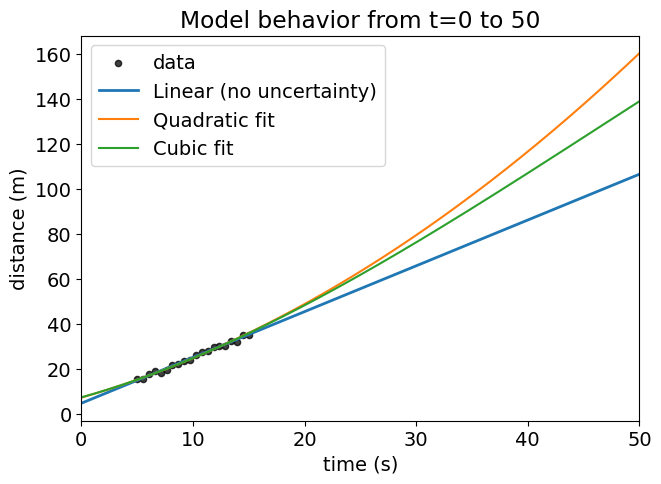

In [32]:
#Code to make more predictions and plot the results.

# evaluation grid
xs = np.linspace(0, 50, 1200)

# linear model without uncertainty (use whatever params you have)
if "bestm" in globals() and "bestb" in globals():
    y_lin = bestb + bestm*xs
elif "m_ml" in globals() and "b_ml" in globals():
    y_lin = b_ml + m_ml*xs
elif "m_wls" in globals() and "b_wls" in globals():
    y_lin = b_wls + m_wls*xs
else:
    raise NameError("Need linear params: bestm/bestb or m_ml/b_ml or m_wls/b_wls.")

# ML models (assumes quad/cubic funcs and p_quad/p_cubic from curve_fit are defined)
y_quad  = quad(xs,  *p_quad)
y_cubic = cubic(xs, *p_cubic)

# plot
plt.figure(figsize=(7.2,5))
# scatter original data if available
t_plot = globals().get("t_arr", globals().get("t_train", globals().get("t10")))
y_plot = globals().get("y_arr", globals().get("y_train", globals().get("y10")))
if t_plot is not None and y_plot is not None:
    plt.scatter(t_plot, y_plot, s=20, c="k", alpha=0.75, label="data")

plt.plot(xs, y_lin,  label="Linear (no uncertainty)", linewidth=2)
plt.plot(xs, y_quad, label="Quadratic fit")
plt.plot(xs, y_cubic,label="Cubic fit")
plt.xlim(0, 50)
plt.xlabel("time (s)")
plt.ylabel("distance (m)")
plt.title("Model behavior from t=0 to 50")
plt.legend()
plt.show()

Now that you've made the plot, you may have a better idea of what's happening when we try to extrapolate from the ML models. What do you observe about the behavior of each model when it's applied to points with feature values outside the training domaain?

Outside the training range, the linear models continue in a straight line and stay consistent with each other, while the quadratic and especially the cubic curve upward and drift farther away. Small coefficient errors in the polynomials grow with t, so their predictions diverge rapidly even though they looked fine on the training data. The tree model cannot meaningfully extrapolate at all and snaps to values seen near the edge of the data. Even thought hte cubic fit preforms better than that of the quadratic later on, it still veers off in its evaluation.

In this notebook, you tested interpolation and extrapolation performance of:
1. The "physically motivated" inference models (linear models)
2. Classical inference-based models with an incorrect underlying model (quadratic and cubic polynomial models)
3. A machine learning decision tree regression model
4. A machine learning linear regression model


Compare the performance in interpolation between these options. 

Inside the data range, the linear models (physically motivated WLS and ML OLS) are the most reliable when the relationship is roughly linear. WLS often edges out OLS if noise is heteroskedastic because it weights precise points more. Quadratic can help only when there’s clear, smooth curvature across the sampled range; cubic usually adds variance on small, noisy sets. Decision trees interpolate with blocky, piecewise-constant steps and tend to underperform for smooth 1-D trends.

-Linear (WLS/OLS): lowest error; stable, interpretable.
-WLS vs OLS: WLS better with unequal noise; otherwise similar.
-Quadratic: useful for real global curvature; but have to watch overfitting.
-Cubic: rarely helpful here; high variance on small data.

Decision tree: stepwise predictions; needs lots of data/regularization.

Compare the performance in extrapolation between these options.

For points beyond the training domain, the linear models are the most reliable when a straight-line relationship is physically justified. The quadratic and cubic quickly deviate and can become very inaccurate as distance grows. The decision tree fails to extrapolate and just returns the nearest leaf value, which there appears to be any safeguard for this being truly accurate. 

What does this tell us about the overall strengths and weaknesses of these methods, and when we may want to use them?

Use simple, theory-backed linear models when data are limited, interpretability matters, or you must extrapolate. Use flexible models like quadratic or cubic only when you have strong evidence of curvature and you will stay near the training range, and always validate on held-out data. Decision trees are useful for nonlinear structure with plenty of data inside the domain, but they are poor for extrapolation. In short, prefer the simplest model that matches known physics and reserve more flexible models for purely predictive tasks within the observed range.

### Acknowledgement Statement

I would like to thank Dr. Gruszko, for allowed me to submit very late, as well as ChatGPT for a lot of the plotting syntax. 